# T2D2 offset-free MPC — CSTR–separator

Closed-loop copy of `T2D2_10.ipynb`, formatted like `N4SID.ipynb`. The prediction model is the Koopman autoencoder from closed-loop HPO (`CSTRSeparator/data/hpo_results/noC_t2t3/cl_winner.json`): files `A/B/C_cstr_separator_C_noc_hpo.npy` (`nz = 25`, depth 2, width 1, ELU, T2D2+T3D3 OF ≈ 304.8).

Latent dynamics stay linear `(A, B)`. The output map is a **nonlinear decoder** `h(x)`, so each sample we linearize

`y ≈ h(x_lp) + J (x − x_lp) + d`, `J = ∂h/∂x |_{x_lp}`

and pass that affine map into the same offset-free pieces as T2D2: **TVKF**, **TaylorTargetEstimation**, **TaylorMPC**. Linearization is at the previous target (T2 / D2). Do not swap these for the linear `KF` / `TargetEstimation` / `MPC` used in N4SID/CT.

**Run this notebook from `CSTRSeparator/Control`** so `sim_setup.pkl` is found by the helper QPs. Generate the pickle first:

```bash
python setup.py
```

## Industrial scenario (same as N4SID)

Two CSTRs in series with a flash separator and recycle (Liu / Li & Swartz). Product quality is bottoms **xB3**; **T1, T2, T3** are regulated temperatures. Manipulated variables: **Q1, Q2, Q3, F10, F20, Fr**.

| Phase | Samples | What happens |
|---|---|---|
| Hold nominal | 0–350 | Li & Swartz steady state |
| Grade change | 350–1000 | Higher-xB3 “premium B” grade (cooler, higher F10) |
| Cold feed | k = 600 | Unmeasured **T10**: 313 → 310 K |
| Lean feed | k = 850 | Unmeasured **xA10**: 1.00 → 0.97 |
| Return | 1000–end | Back to nominal grade; feed upsets stay on |

Disturbances are plant-parameter changes only. Observer, target, and MPC reject them through the output-disturbance estimate on the linearized output map.

In [6]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import joblib
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

HERE = Path.cwd().resolve()
REPO_ROOT = HERE.parent.parent
DATA_DIR = HERE.parent / "data"
SRC_PATH = REPO_ROOT / "src"
if SRC_PATH.as_posix() not in sys.path:
    sys.path.append(SRC_PATH.as_posix())
if HERE.as_posix() not in sys.path:
    sys.path.append(HERE.as_posix())

import helper
import plant_inference

In [7]:
plant_inference.init()
scaler, scalerU = plant_inference.scaler, plant_inference.scalerU

# Closed-loop HPO best (noC / T2D2+T3D3). Snapshot of trial 507, nz=25, OF≈304.8.
# See ../data/hpo_results/noC_t2t3/cl_winner.json
ABC_STEM = "cstr_separator_C_noc_hpo"
A = np.load((DATA_DIR / f"A_{ABC_STEM}.npy").as_posix()).astype(float)
B = np.load((DATA_DIR / f"B_{ABC_STEM}.npy").as_posix()).astype(float)
C_ls = np.load((DATA_DIR / f"C_{ABC_STEM}.npy").as_posix()).astype(float)

nz, nu = B.shape
ny = C_ls.shape[0]
nd = ny
print(
    f"T2D2 Koopman  A {A.shape}  B {B.shape}  C_ls {C_ls.shape}  "
    f"rho(A)={np.max(np.abs(np.linalg.eigvals(A))):.4f}"
)

problem, _, _, _ = helper.build_koopman_problem(
    ny=ny,
    nu=nu,
    nz=nz,
    matrix_C=False,
    encoder_depth=2,
    width_mult=1.0,
    nonlin="elu",
    loss_weights=helper.LossWeights(),
    nsteps=1,
)
problem.load_state_dict(
    torch.load((DATA_DIR / f"model_{ABC_STEM}.pth").as_posix(), map_location="cpu"),
    strict=True,
)
problem.eval()

def get_x(y: np.ndarray) -> np.ndarray:
    x = problem.nodes[0]({"Y0": torch.from_numpy(np.asarray(y, dtype=np.float32))})
    return x["x"].detach().numpy().reshape(1, -1).T

def get_y(x: np.ndarray) -> np.ndarray:
    y = problem.nodes[4]({"x": torch.from_numpy(np.asarray(x, dtype=np.float32).T)})
    return y["yhat"].detach().numpy().reshape(1, -1)

def jacobian_at(z: np.ndarray) -> np.ndarray:
    x_lp = torch.from_numpy((T_real @ np.asarray(z, dtype=float).reshape(-1)).astype(np.float32))
    return helper.evaluate_jacobian(problem.nodes[4], x_lp) @ T_real

T_real, A_block = helper.ident.real_block_diagonalize(A)
A_transformed = inv(T_real) @ A @ T_real
print("Close to block diagonal?", np.allclose(A_block, A_transformed, atol=1e-6))
print("Backtransformation equals A?", np.allclose(A, T_real @ A_block @ inv(T_real), atol=1e-6))

A = A_block
B = inv(T_real) @ B
C = C_ls @ T_real

loaded_setup = joblib.load("sim_setup.pkl")
y_names = loaded_setup["y_names"]
u_names = loaded_setup["u_names"]
Ts = float(loaded_setup["Ts"])

T2D2 Koopman  A (25, 25)  B (25, 6)  C_ls (4, 25)  rho(A)=0.9507
Close to block diagonal? True
Backtransformation equals A? True


In [8]:
y_start = loaded_setup["y_start"]
y_start_ns = loaded_setup["y_start_ns"]
reference = loaded_setup["reference"]
reference_ns = loaded_setup["reference_ns"]
y_setpoint = reference[:, 0]
u_previous = loaded_setup["u_previous"]
u_sp = loaded_setup["reference_u"]

z_est_ = np.hstack(((inv(T_real) @ get_x(y_start)).T, np.zeros((1, nd))))
P0 = np.eye(nz + nd) * loaded_setup["P0"]
Q = np.block(
    [
        [np.eye(nz) * loaded_setup["Q"], np.zeros((nz, nd))],
        [np.zeros((nd, nz)), np.eye(nd) * loaded_setup["Qd"]],
    ]
)
R = np.eye(ny) * loaded_setup["R"]
Cd = np.eye(ny)
Bd = np.zeros((nz, nd))

A_ = np.block([[A, Bd], [np.zeros((nd, nz)), np.eye(nd)]])
B_ = np.vstack([B, np.zeros((nd, nu))])
C_ = np.hstack([C, Cd])
TVKF = helper.TVKF(A_, B_, C_, z_est_, P0, Q, R)

J = jacobian_at(z_est_[0, :nz])
y_lp = get_y(T_real @ z_est_[0, :nz])
target_estimation = helper.TaylorTargetEstimation(
    A, B, loaded_setup["Qy"], loaded_setup["Qu_te"], Bd, Cd
)
z_s, y_s, u_s = target_estimation.get_target(
    z_est_[:, nz:], y_setpoint, u_sp, y_lp, z_est_[0, :nz], J
)
z_ref = z_s
print("Initial target y error (scaled):", y_s - y_setpoint)

J = jacobian_at(z_s)
Qz = J.T @ loaded_setup["Qy"] @ J
Qz_psd = Qz + 1e-8 * np.eye(nz)
print("Qz PSD?", np.all(np.linalg.eigvalsh(Qz_psd) >= -1e-10))
print("Qu PSD?", np.all(np.linalg.eigvalsh(loaded_setup["Qu"]) >= -1e-10))

mpc = helper.TaylorMPC(
    A, B, loaded_setup["Qy"], loaded_setup["Qu"], loaded_setup["Qdu"], Bd, Cd
)
mpc.build_problem()
_ = mpc.get_u_optimal(
    z_est_[0, :nz],
    z_est_[:, nz:],
    u_previous,
    z_ref,
    u_s,
    get_y(T_real @ z_s),
    z_s,
    J,
    Qz_psd,
)

sim_time = int(loaded_setup["sim_time"])
plant_inference.reset(loaded_setup["x_start"], Ts=Ts)

Initial target y error (scaled): [ 6.69669218e-08 -1.86578593e-07  1.64574069e-07  3.27019833e-09]
Qz PSD? True
Qu PSD? True


/Users/patrik/miniconda3/envs/kmpc/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain.py:245: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  warnings.warn(DPP_ERROR_MSG)


In [9]:
z_sim = np.zeros((nz + nd, sim_time + 1))
y_sim = np.zeros((ny, sim_time + 1))
u_sim = np.zeros((nu, sim_time))
us_sim = np.zeros((nu, sim_time))
ys_sim = np.zeros((ny, sim_time + 1))
zs_sim = np.zeros((nz, sim_time + 1))
y_sim_ns = np.zeros((ny, sim_time + 1))
y_true_ns = np.zeros((ny, sim_time + 1))
u_sim_ns = np.zeros((nu, sim_time))
x_sim = np.zeros((9, sim_time + 1))

z_sim[:, 0] = z_est_.flatten()
y_sim[:, 0] = y_start.flatten()
y_sim_ns[:, 0] = np.asarray(y_start_ns).flatten()
y_true_ns[:, 0] = plant_inference.measure_ns()
x_sim[:, 0] = plant_inference.x.copy()
ys_sim[:, 0] = y_s
zs_sim[:, 0] = z_s
u_prev = np.asarray(u_s).reshape(-1)

J = jacobian_at(zs_sim[:, 0])
Qy = loaded_setup["Qy"]

disturbances = list(loaded_setup["disturbances"])
dist_by_k = {int(d["k"]): d for d in disturbances}
noise_sigma = np.asarray(loaded_setup["noise_sigma"], dtype=float)
rng = np.random.default_rng(0)

for k in tqdm(range(sim_time), desc="Closed-loop simulation", ncols=80):
    if k in dist_by_k:
        d = dist_by_k[k]
        plant_inference.apply_disturbance(d["attr"], d["value"])
        print(f"k={k}: {d['label']}")

    idx_prev = max(k - 1, 0)
    y_lp = get_y(T_real @ zs_sim[:, idx_prev])
    zs_sim[:, k], ys_sim[:, k], us_sim[:, k] = target_estimation.get_target(
        z_sim[nz:, k],
        reference[:, k],
        u_sp,
        y_lp,
        zs_sim[:, idx_prev],
        J,
    )

    Qz_psd = J.T @ Qy @ J + 1e-8 * np.eye(nz)
    u_opt = mpc.get_u_optimal(
        z_sim[:nz, k],
        z_sim[nz:, k],
        u_prev,
        zs_sim[:, k],
        us_sim[:, k],
        y_lp,
        zs_sim[:, idx_prev],
        J,
        Qz_psd,
    )
    u_sim[:, k] = u_opt
    u_sim_ns[:, k] = scalerU.inverse_transform(u_sim[:, k].reshape(1, -1))[0]

    y_next = plant_inference.y_plus(u_sim[:, k])
    y_true_ns[:, k + 1] = plant_inference.measure_ns()
    x_sim[:, k + 1] = plant_inference.x.copy()
    noise = rng.normal(0.0, noise_sigma)
    y_meas_ns = y_true_ns[:, k + 1] + noise
    y_sim[:, k + 1] = scaler.transform(y_meas_ns.reshape(1, -1))[0]
    y_sim_ns[:, k + 1] = y_meas_ns

    J = jacobian_at(zs_sim[:, k])
    C_k = np.hstack([J, Cd])
    z_sim[:, k + 1] = TVKF.step(
        u_sim[:, k],
        y_sim[:, k + 1],
        get_y(T_real @ zs_sim[:nz, k]),
        zs_sim[:nz, k],
        J,
        C_k,
    ).flatten()
    u_prev = u_sim[:, k]

Closed-loop simulation:  40%|██████▍         | 601/1500 [02:19<03:19,  4.51it/s]

k=600: cold feed T10: 313 -> 310 K


Closed-loop simulation:  57%|█████████       | 850/1500 [03:15<02:36,  4.16it/s]

k=850: lean feed xA10: 1.00 -> 0.97


Closed-loop simulation: 100%|███████████████| 1500/1500 [05:43<00:00,  4.37it/s]


Closed-loop objective function value: 232.28829144761403
  - State tracking term: 135.7370026559654
  - Input increment term: 57.894692537046865
  - Input setpoint term: 38.65659625460142


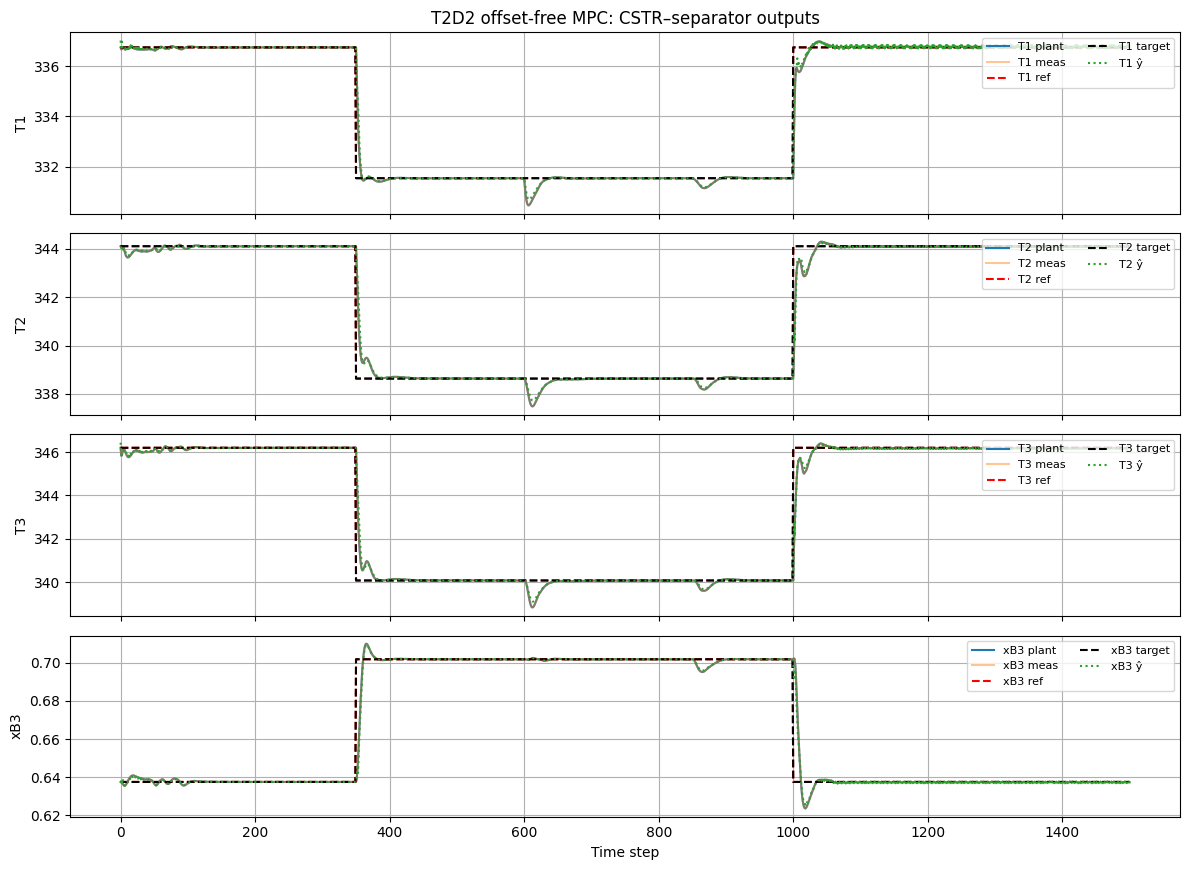

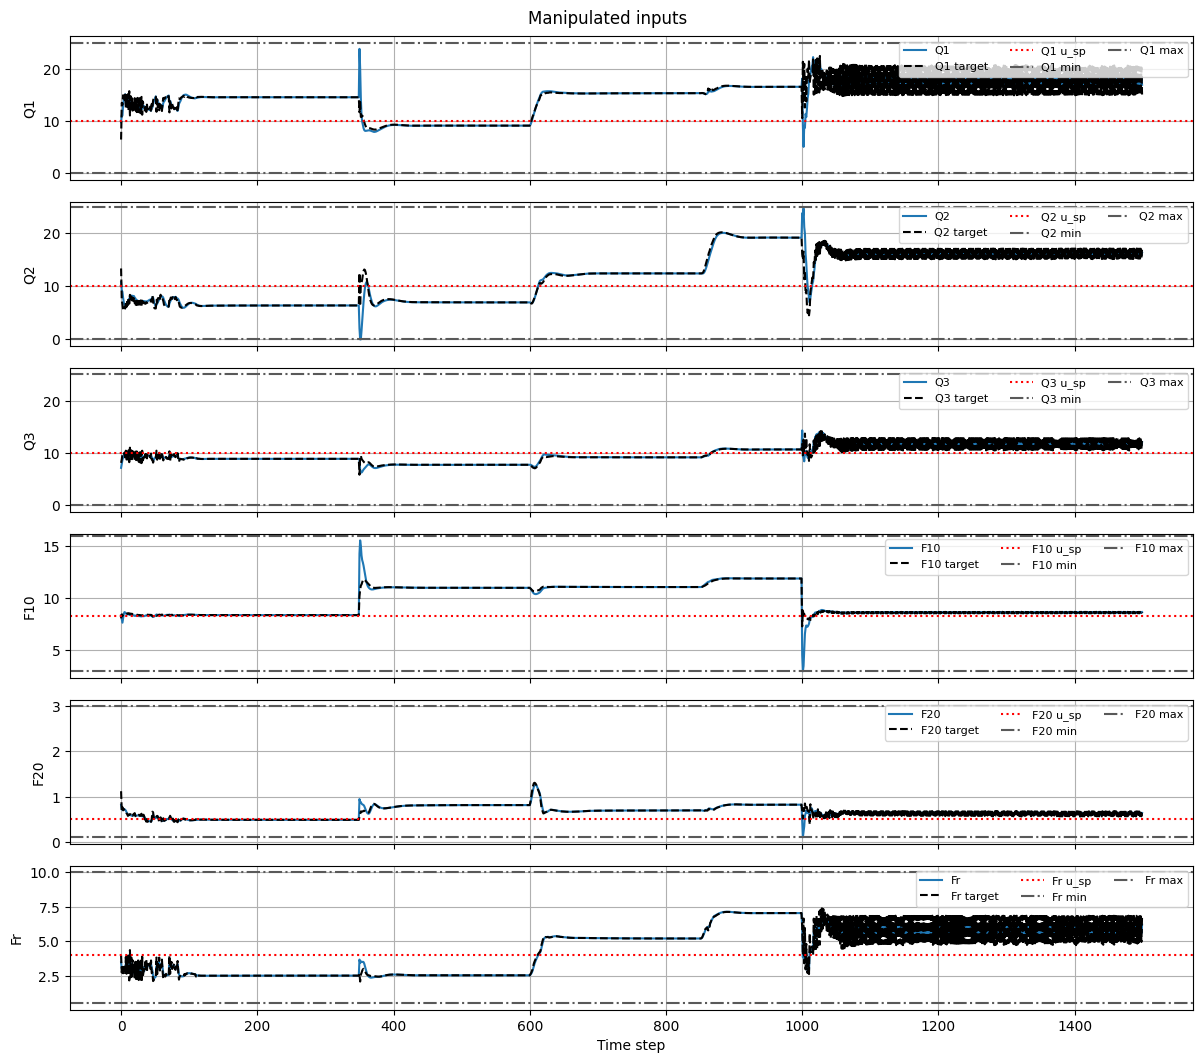

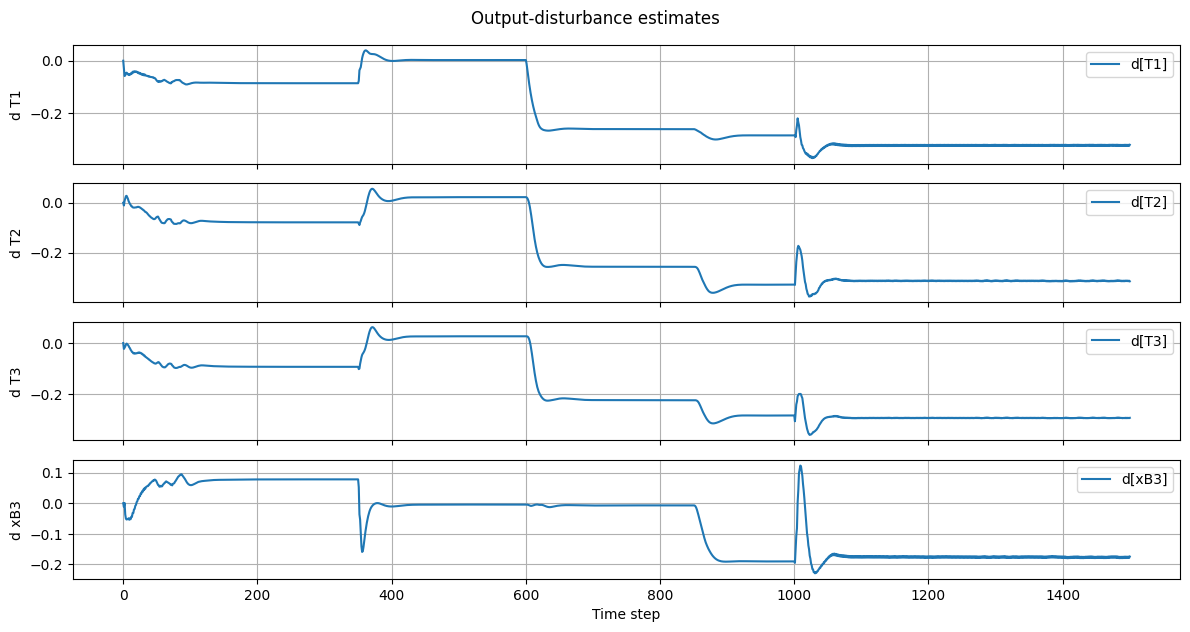

In [10]:
Qy, Qu, Qdu = loaded_setup["Qy"], loaded_setup["Qu"], loaded_setup["Qdu"]
objective_value = state_error_cost = control_increment_cost = control_setpoint_cost = 0.0
for k in range(sim_time):
    y_diff = y_sim[:, k] - reference[:, k]
    prev_u = u_sim[:, k - 1] if k > 0 else u_sim[:, k]
    u_diff = u_sim[:, k] - prev_u
    u_error = us_sim[:, k] - u_sim[:, k]
    y_term = float(y_diff.T @ Qy @ y_diff)
    u_term = float(u_diff.T @ Qdu @ u_diff)
    u_sp_term = float(u_error.T @ Qu @ u_error)
    state_error_cost += y_term
    control_increment_cost += u_term
    control_setpoint_cost += u_sp_term
    objective_value += y_term + u_term + u_sp_term

print(f"Closed-loop objective function value: {objective_value}")
print(f"  - State tracking term: {state_error_cost}")
print(f"  - Input increment term: {control_increment_cost}")
print(f"  - Input setpoint term: {control_setpoint_cost}")

ys_sim_ns = scaler.inverse_transform(ys_sim.T).T
us_sim_ns = scalerU.inverse_transform(us_sim.T).T
y_hat = np.zeros((ny, sim_time + 1))
for k in range(sim_time + 1):
    y_hat[:, k] = get_y(T_real @ z_sim[:nz, k]).ravel() + z_sim[nz:, k]
y_hat_ns = scaler.inverse_transform(y_hat.T).T

n_steps = sim_time
fig, axs = plt.subplots(ny, 1, figsize=(12, 2.2 * ny), sharex=True)
for i, name in enumerate(y_names):
    axs[i].plot(y_true_ns[i, :], label=f"{name} plant")
    axs[i].plot(y_sim_ns[i, :], alpha=0.45, label=f"{name} meas")
    axs[i].plot(reference_ns[i, :n_steps], "r--", label=f"{name} ref")
    axs[i].plot(ys_sim_ns[i, :n_steps], "k--", label=f"{name} target")
    axs[i].plot(y_hat_ns[i, :], ":", label=f"{name} ŷ")
    axs[i].set_ylabel(name)
    axs[i].grid(True)
    axs[i].legend(loc="upper right", ncol=2, fontsize=8)
axs[-1].set_xlabel("Time step")
axs[0].set_title("T2D2 offset-free MPC: CSTR–separator outputs")
fig.tight_layout()

fig_u, axs_u = plt.subplots(nu, 1, figsize=(12, 1.8 * nu), sharex=True)
u_sp_ns = scalerU.inverse_transform(u_sp.reshape(1, -1))[0]
u_min_ns = np.asarray(loaded_setup["u_min_ns"], dtype=float).reshape(-1)
u_max_ns = np.asarray(loaded_setup["u_max_ns"], dtype=float).reshape(-1)
for i, name in enumerate(u_names):
    axs_u[i].plot(u_sim_ns[i, :], label=name)
    axs_u[i].plot(us_sim_ns[i, :], "k--", label=f"{name} target")
    axs_u[i].axhline(u_sp_ns[i], color="r", linestyle=":", label=f"{name} u_sp")
    axs_u[i].axhline(u_min_ns[i], color="0.35", linestyle="-.", label=f"{name} min")
    axs_u[i].axhline(u_max_ns[i], color="0.35", linestyle="-.", label=f"{name} max")
    axs_u[i].set_ylabel(name)
    axs_u[i].grid(True)
    axs_u[i].legend(loc="upper right", ncol=3, fontsize=8)
axs_u[-1].set_xlabel("Time step")
fig_u.suptitle("Manipulated inputs")
fig_u.tight_layout()

fig_d, axs_d = plt.subplots(nd, 1, figsize=(12, 1.6 * nd), sharex=True)
for i in range(nd):
    axs_d[i].plot(z_sim[nz + i, :], label=f"d[{y_names[i]}]")
    axs_d[i].set_ylabel(f"d {y_names[i]}")
    axs_d[i].grid(True)
    axs_d[i].legend()
axs_d[-1].set_xlabel("Time step")
fig_d.suptitle("Output-disturbance estimates")
fig_d.tight_layout()